In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [2]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 452kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 8.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 41.4MB/s]


In [4]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    def forward(self, x):
        return self.network(x)
    
model = FashionClassifier().to(device)

print(model)

FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)


Epoch  1/15 | Train Loss: 0.3774, Acc: 0.8645 | Val Loss: 0.4223, Acc: 0.8481
Epoch  2/15 | Train Loss: 0.3302, Acc: 0.8794 | Val Loss: 0.3820, Acc: 0.8598
Epoch  3/15 | Train Loss: 0.3201, Acc: 0.8813 | Val Loss: 0.3770, Acc: 0.8640
Epoch  4/15 | Train Loss: 0.2856, Acc: 0.8948 | Val Loss: 0.3585, Acc: 0.8715
Epoch  5/15 | Train Loss: 0.2698, Acc: 0.9003 | Val Loss: 0.3408, Acc: 0.8761
Epoch  6/15 | Train Loss: 0.2503, Acc: 0.9082 | Val Loss: 0.3260, Acc: 0.8820
Epoch  7/15 | Train Loss: 0.2350, Acc: 0.9141 | Val Loss: 0.3214, Acc: 0.8845
Epoch  8/15 | Train Loss: 0.2243, Acc: 0.9162 | Val Loss: 0.3174, Acc: 0.8855
Epoch  9/15 | Train Loss: 0.2105, Acc: 0.9229 | Val Loss: 0.3069, Acc: 0.8884
Epoch 10/15 | Train Loss: 0.1973, Acc: 0.9276 | Val Loss: 0.2994, Acc: 0.8939
Epoch 12/15 | Train Loss: 0.1803, Acc: 0.9345 | Val Loss: 0.2949, Acc: 0.8967
Epoch 15/15 | Train Loss: 0.1691, Acc: 0.9384 | Val Loss: 0.2878, Acc: 0.8980

Best Validation Accuracy: 0.8980 at Epoch 15


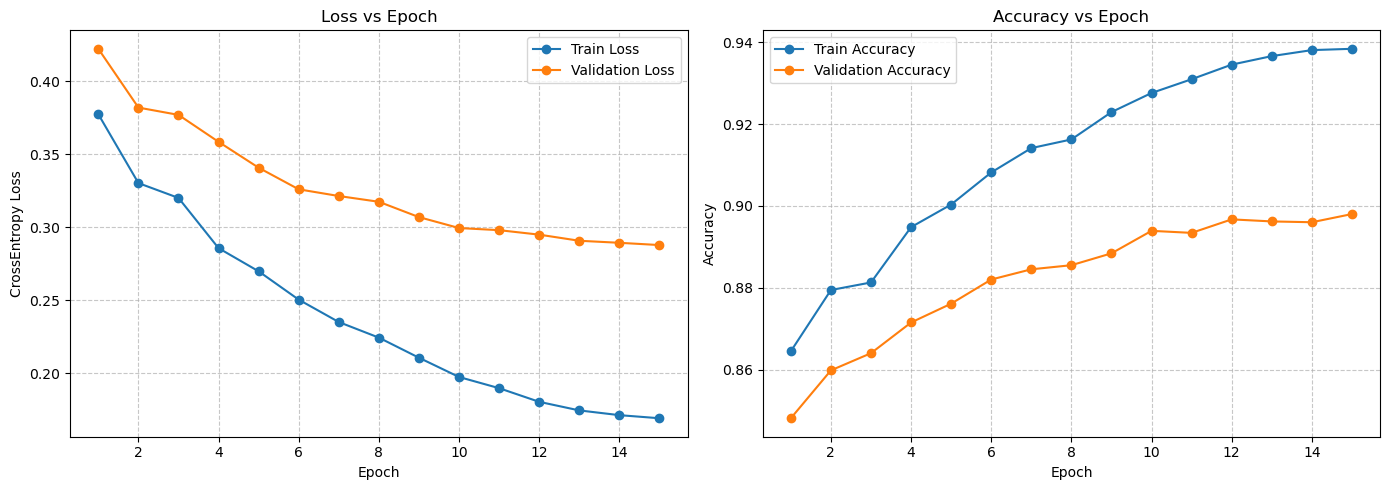

In [7]:
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
best_epoch = 0

def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0 
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs,1)
            total+= labels.size(0)
            correct += (predicted == labels).sum().item()
        return running_loss/total, correct/total
    
for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    scheduler.step()
    train_loss,train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc>best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        print(f"Epoch {epoch+1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

validation loss and accuracy stabilizing nearly somewhere at epochs 10-12 and after that cosine annealing reduces learning rate. As expected best validation score is 89.8. training and validation loss start more close and diverges across epochs. Validation accuracy stops improving nearly at epoch 10-12.